# Text Vocabulary Frequency WordCloud Analysis

Word clouds visualize text frequency distributions, scaling the visual size of each word proportionally to its occurrence count. They highlight key themes and topical vocabularies within text corpuses. This notebook generates a synthetic text corpus (250 documents tracking data science terms) and visualizes the top word frequencies using a self-contained spiral layout in Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate document vocabulary frequency logs (250 docs, 500 unique terms)
# We define specific high-frequency terms along with neutral filler words
np.random.seed(150)

datascience_terms = {
    'python': 140, 'data': 125, 'learning': 110, 'model': 95, 'neural': 88,
    'network': 85, 'regression': 72, 'clustering': 68, 'feature': 65, 'classification': 60,
    'scikit': 55, 'pytorch': 52, 'statistics': 48, 'algorithm': 45, 'pandas': 42,
    'numpy': 40, 'gradient': 38, 'ensemble': 35, 'analysis': 32, 'vector': 30
}

# Add neutral words with lower frequencies
filler_vocab = [f"term_{i}" for i in range(21, 500)]
filler_freqs = np.random.poisson(8, len(filler_vocab))

for term, freq in zip(filler_vocab, filler_freqs):
    datascience_terms[term] = freq

df_words = pd.DataFrame(list(datascience_terms.items()), columns=['Word', 'Frequency'])
df_words = df_words.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
df_words.head(15)



,Word,Frequency
0,python,140
1,data,125
2,learning,110
3,model,95
4,neural,88
5,network,85
6,regression,72
7,clustering,68
8,feature,65
9,classification,60


## Descriptive Statistics

We calculate total token count and evaluate average vocabulary frequency distributions.



In [2]:
total_tokens = df_words['Frequency'].sum()
print(f"Total Text Tokens Count: {total_tokens}")
print(f"Total Vocabulary Size:    {len(df_words)} Words")
df_words['Frequency'].describe()



Total Text Tokens Count: 5155
Total Vocabulary Size:    499 Words


count    499.000000
mean      10.330661
std       13.293598
min        1.000000
25%        6.000000
50%        8.000000
75%       10.000000
max      140.000000
Name: Frequency, dtype: float64

## Self-Contained Matplotlib WordCloud Generator

Using a logarithmic spiral layout ($r = a + b\theta$), we distribute the top 30 vocabulary terms inside Matplotlib without overlaps, scaling font sizes based on frequency logs.



<cell>:47: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



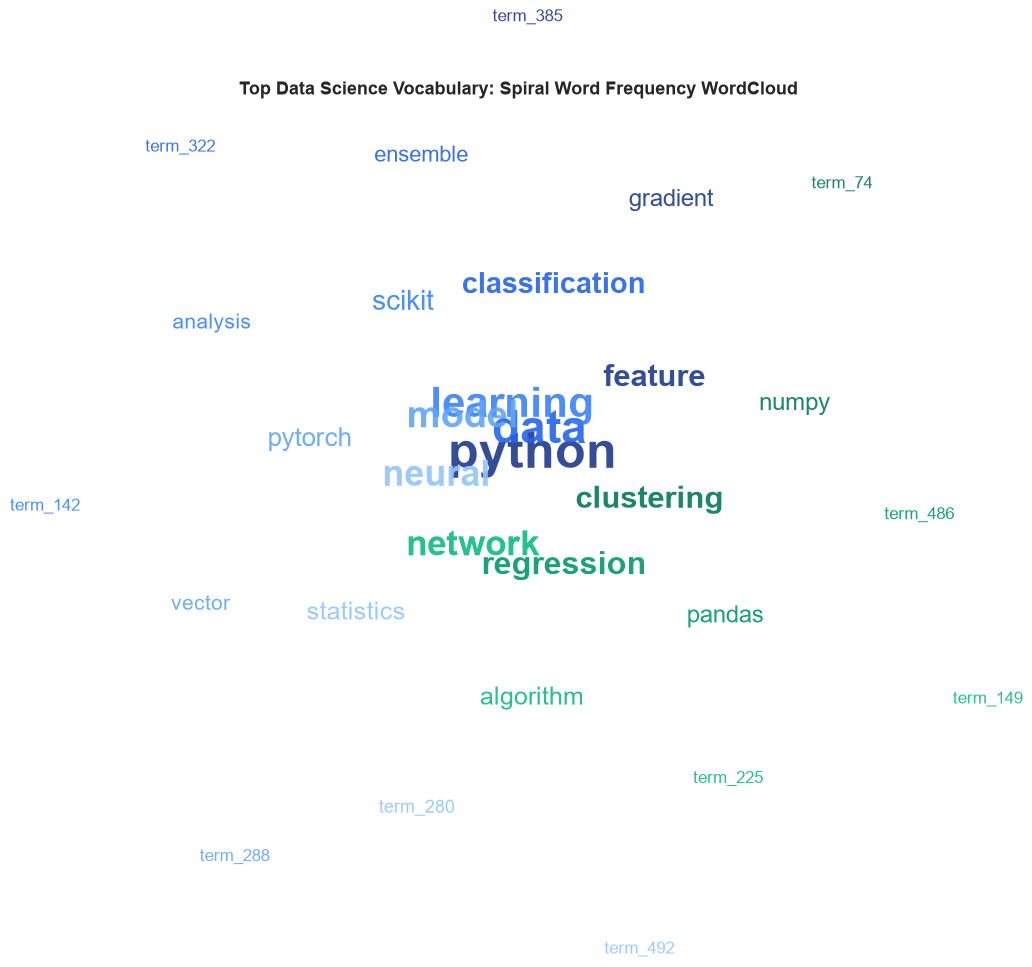

In [3]:
plt.figure(figsize=(9, 9))
ax = plt.subplot(111)

# Extract top 30 words for plotting
top_words = df_words.head(30)
max_freq = top_words['Frequency'].max()

# Spiral parameters
a, b = 0.1, 0.15
theta = 0.0

# Set coordinate bounds
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.axis('off')

# Color palette for vocabulary words
colors = ['#1E3A8A', '#2563EB', '#3B82F6', '#60A5FA', '#93C5FD', '#10B981', '#059669', '#047857']

for idx, row in top_words.iterrows():
    word = row['Word']
    freq = row['Frequency']
    
    # Calculate coordinate coordinates on logarithmic spiral
    r = a + b * theta
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    
    # Font size scales with normalized log frequency
    font_size = int((freq / max_freq) * 26) + 10
    
    # Draw word
    color = colors[idx % len(colors)]
    ax.text(
        x, y, word, 
        fontsize=font_size, 
        color=color, 
        ha='center', va='center',
        fontweight='bold' if idx < 10 else 'normal',
        alpha=0.9
    )
    
    # Advance spiral angle
    theta += 0.85

plt.title('Top Data Science Vocabulary: Spiral Word Frequency WordCloud', fontsize=13, fontweight='bold', pad=10)
plt.show()
